 Fake News Detection Project

 CELL 1: Install Required Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn
!pip install scikit-learn
!pip install nltk
!pip install wordcloud

 CELL 2: Import All Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud

# NLTK for text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')


In [6]:
# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All libraries imported successfully! ✓")


All libraries imported successfully! ✓


 CELL 3: Load the Dataset

In [8]:
# Load your dataset - update the path as needed
df = pd.read_csv('C:\\Users\\shiva\\Desktop\\datasets\\news.csv')

In [9]:
# The dataset should have columns like 'text' and 'label'
# label: 0 = Fake news, 1 = Real news

print(f"Dataset loaded!")
print(f"Total articles: {len(df)}")
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded!
Total articles: 6335

First few rows:
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [12]:
print(f"\nChecking for missing values:")
print(df.isnull().sum())

print(f"\nNews distribution:")
print(df['label'].value_counts())



Checking for missing values:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

News distribution:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


 CELL 4: Let's Visualize the Data

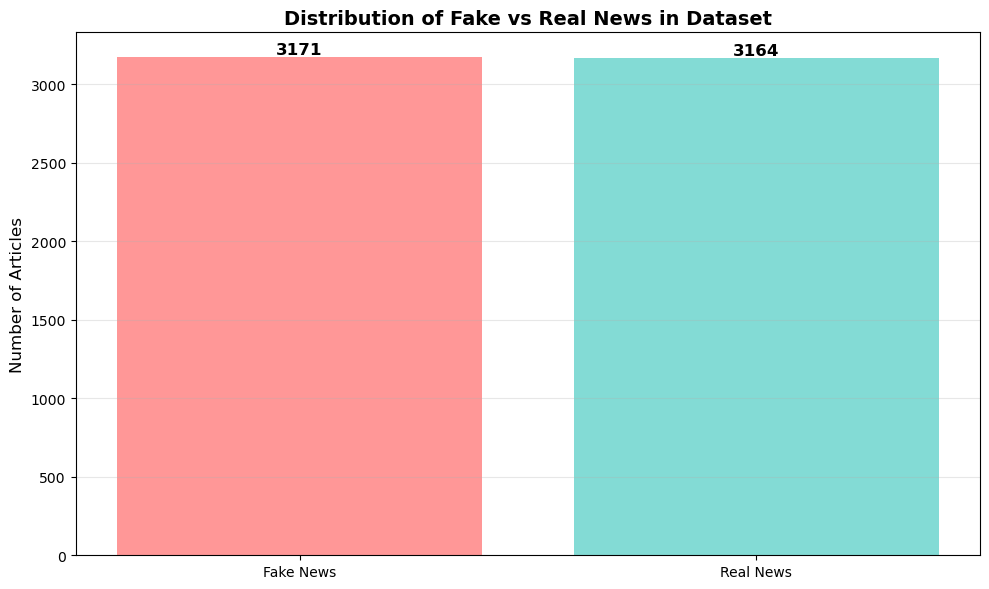

In [13]:
# Create a nice bar chart showing fake vs real news
plt.figure(figsize=(10, 6))
counts = df['label'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']  # Red for fake, teal for real
bars = plt.bar(['Fake News', 'Real News'], counts.values, color=colors, alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Fake vs Real News in Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Number of Articles', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 CELL 5: Text Cleaning Function

In [14]:
def clean_text(text):
    """
    Clean and prepare text for analysis
    """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove @ mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra spaces
    text = ' '.join(text.split())
    
    return text


 CELL 6: Remove Stopwords

In [15]:
def remove_stopwords(text):
    """
    Remove common words that don't add much meaning
    """
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_words)


 CELL 7: Lemmatization

In [16]:
def lemmatize_text(text):
    """
    Convert words to their base form (e.g., 'running' -> 'run')
    """
    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)

 CELL 8: Apply All Preprocessing

In [24]:
# Combine title and text if both exist
if 'title' in df.columns and 'text' in df.columns:
    df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
elif 'text' in df.columns:
    df['content'] = df['text']
else:
    df['content'] = df['title']


import nltk

nltk.download('punkt')
nltk.download('punkt_tab')     # ← This is the missing one
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')       # Optional, for lemmatization


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [25]:
# Remove duplicates
df = df.drop_duplicates(subset=['content'])
df = df.reset_index(drop=True)

print("Cleaning the text data... (this might take a minute)")

# Apply all cleaning steps
df['cleaned_text'] = df['content'].apply(clean_text)
df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)
df['cleaned_text'] = df['cleaned_text'].apply(lemmatize_text)


Cleaning the text data... (this might take a minute)


In [27]:
# Remove empty texts
df = df[df['cleaned_text'].str.strip() != '']
df = df.reset_index(drop=True)

print(f"\n✓ Cleaning complete!")
print(f"Dataset shape after cleaning: {df.shape}")

# Show before and after
print(f"\nExample - Before cleaning:")
print(df['content'].iloc[0][:200])
print(f"\nExample - After cleaning:")
print(df['cleaned_text'].iloc[0][:200])



✓ Cleaning complete!
Dataset shape after cleaning: (6306, 6)

Example - Before cleaning:
You Can Smell Hillary’s Fear Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodha

Example - After cleaning:
smell hillary fear daniel greenfield shillman journalism fellow freedom center new york writer focusing radical islam final stretch election hillary rodham clinton gone war fbi word unprecedented thro


CELL 9: Word Clouds - Visual Analysis


In [33]:
print("Label values:", df['label'].unique())
print("Fake news count:", len(df[df['label'] == 0]))
print("Real news count:", len(df[df['label'] == 1]))

print("Empty cleaned_text values:", df['cleaned_text'].isna().sum())
print("Example fake text sample:", df[df['label'] == 0]['cleaned_text'].head())


Label values: ['FAKE' 'REAL']
Fake news count: 0
Real news count: 0
Empty cleaned_text values: 0
Example fake text sample: Series([], Name: cleaned_text, dtype: object)


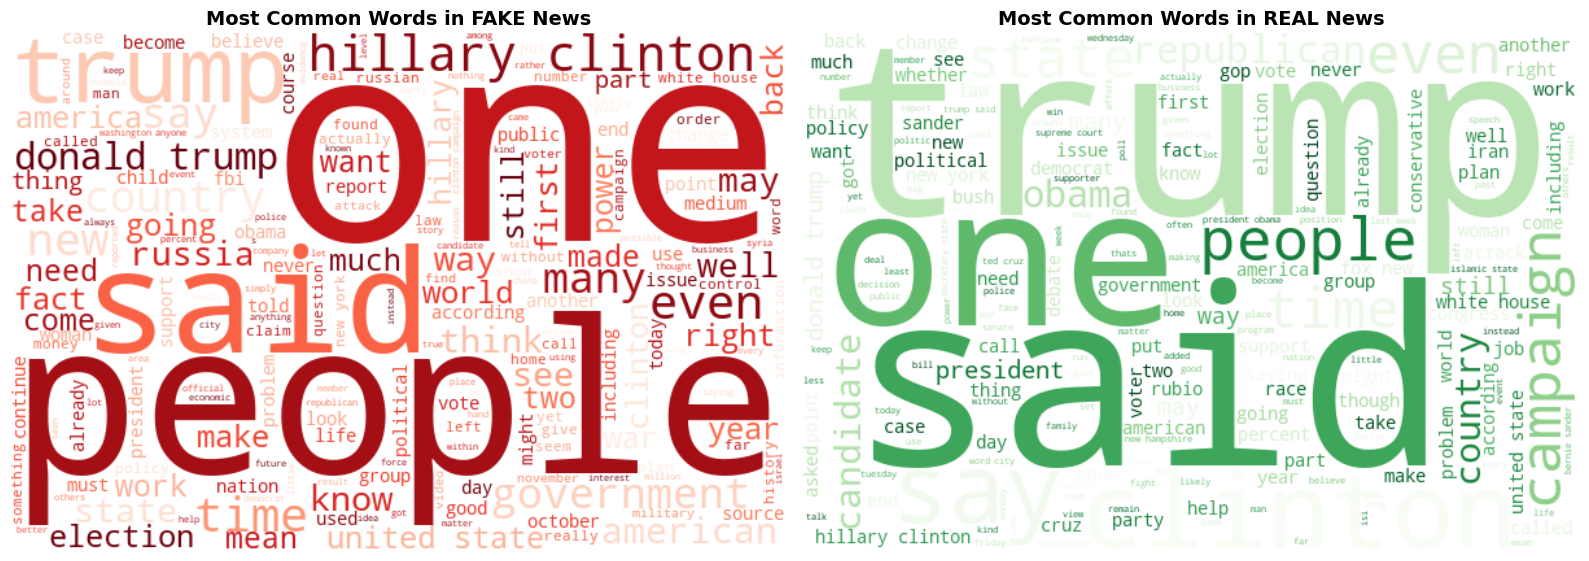

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Fake news word cloud
fake_text = ' '.join(df[df['label'] == 'FAKE']['cleaned_text'].dropna().values)
wordcloud_fake = WordCloud(width=600, height=400, 
                           background_color='white',
                           colormap='Reds').generate(fake_text)
ax1.imshow(wordcloud_fake, interpolation='bilinear')
ax1.set_title('Most Common Words in FAKE News', fontsize=14, fontweight='bold')
ax1.axis('off')

# Real news word cloud
real_text = ' '.join(df[df['label'] == 'REAL']['cleaned_text'].dropna().values)
wordcloud_real = WordCloud(width=600, height=400, 
                           background_color='white',
                           colormap='Greens').generate(real_text)
ax2.imshow(wordcloud_real, interpolation='bilinear')
ax2.set_title('Most Common Words in REAL News', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


 CELL 10: Text Statistics

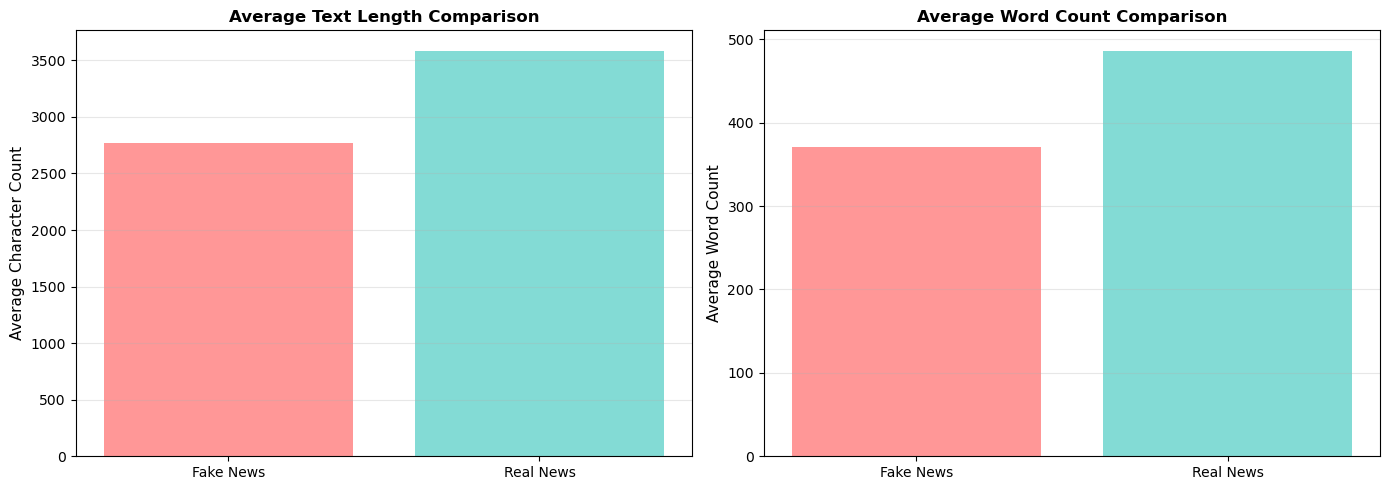

In [35]:
# Let's see if fake and real news have different characteristics
df['text_length'] = df['cleaned_text'].apply(len)
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Average text length
avg_lengths = df.groupby('label')['text_length'].mean()
ax1.bar(['Fake News', 'Real News'], avg_lengths.values, 
        color=['#FF6B6B', '#4ECDC4'], alpha=0.7)
ax1.set_ylabel('Average Character Count', fontsize=11)
ax1.set_title('Average Text Length Comparison', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Average word count
avg_words = df.groupby('label')['word_count'].mean()
ax2.bar(['Fake News', 'Real News'], avg_words.values, 
        color=['#FF6B6B', '#4ECDC4'], alpha=0.7)
ax2.set_ylabel('Average Word Count', fontsize=11)
ax2.set_title('Average Word Count Comparison', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

 CELL 11: Split Data into Train and Test

In [36]:
# Prepare our data
X = df['cleaned_text']
y = df['label']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split complete!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print(f"\nTraining set distribution:")
print(y_train.value_counts())
print(f"\nTest set distribution:")
print(y_test.value_counts())


Data split complete!
Training samples: 5044
Testing samples: 1262

Training set distribution:
label
REAL    2523
FAKE    2521
Name: count, dtype: int64

Test set distribution:
label
REAL    631
FAKE    631
Name: count, dtype: int64


CELL 12: Convert Text to Numbers (TF-IDF)

In [37]:
# Machine learning models need numbers, not text
# TF-IDF helps us convert text into meaningful numbers

print("Converting text to numerical features...")

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✓ Conversion complete!")
print(f"Feature matrix shape (train): {X_train_tfidf.shape}")
print(f"Feature matrix shape (test): {X_test_tfidf.shape}")


Converting text to numerical features...
✓ Conversion complete!
Feature matrix shape (train): (5044, 5000)
Feature matrix shape (test): (1262, 5000)


 CELL 13: Train Multiple Models


In [39]:
# Let's try different algorithms and see which works best!

print("Training different models...\n")
print("=" * 70)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_tfidf, y_train)
    
    # Make predictions
    predictions = model.predict(X_test_tfidf)
    
    # Calculate metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, pos_label='FAKE')
    rec = recall_score(y_test, predictions, pos_label='FAKE')
    f1 = f1_score(y_test, predictions, pos_label='FAKE')

    # Store results
    results[name] = {
        'model': model,
        'predictions': predictions,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    
    print(f"  ✓ Accuracy:  {acc:.4f}")
    print(f"  ✓ Precision: {prec:.4f}")
    print(f"  ✓ Recall:    {rec:.4f}")
    print(f"  ✓ F1-Score:  {f1:.4f}")

print("\n" + "=" * 70)
print("All models trained!")


Training different models...


Training Logistic Regression...
  ✓ Accuracy:  0.9113
  ✓ Precision: 0.9048
  ✓ Recall:    0.9192
  ✓ F1-Score:  0.9119

Training Naive Bayes...
  ✓ Accuracy:  0.8716
  ✓ Precision: 0.8474
  ✓ Recall:    0.9065
  ✓ F1-Score:  0.8760

Training Passive Aggressive...
  ✓ Accuracy:  0.9168
  ✓ Precision: 0.9201
  ✓ Recall:    0.9128
  ✓ F1-Score:  0.9165

Training Random Forest...
  ✓ Accuracy:  0.8994
  ✓ Precision: 0.8925
  ✓ Recall:    0.9081
  ✓ F1-Score:  0.9002

All models trained!


 CELL 14: Compare Model Performance


📊 Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.911252   0.904836 0.919176  0.911950
        Naive Bayes  0.871632   0.847407 0.906498  0.875957
 Passive Aggressive  0.916799   0.920128 0.912837  0.916468
      Random Forest  0.899366   0.892523 0.908082  0.900236


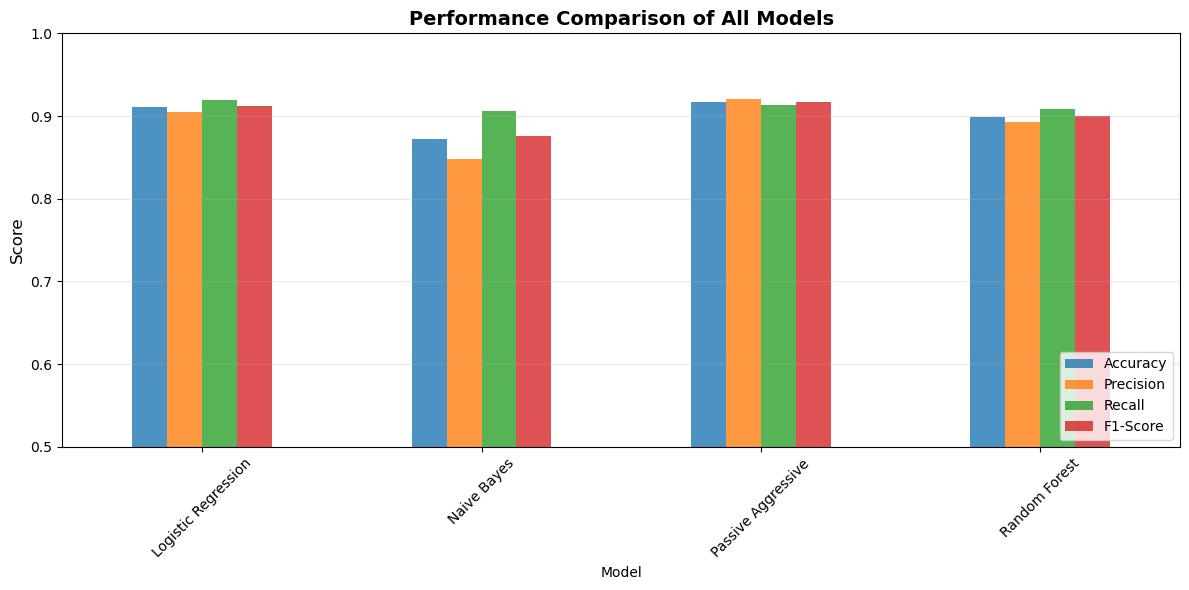

In [40]:
# Create a comparison table
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1_score'] for m in results]
})

print("\n📊 Model Performance Comparison:")
print(comparison.to_string(index=False))

# Visualize the comparison
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(12, 6), rot=45, alpha=0.8
)
plt.title('Performance Comparison of All Models', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 CELL 15: Select the Best Model

In [41]:
# Find the model with highest F1-score
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"   F1-Score: {results[best_model_name]['f1_score']:.4f}")

# Detailed report for best model
print(f"\n📋 Detailed Classification Report for {best_model_name}:")
print(classification_report(y_test, best_predictions, 
                          target_names=['Fake News', 'Real News']))



🏆 Best Performing Model: Passive Aggressive
   F1-Score: 0.9165

📋 Detailed Classification Report for Passive Aggressive:
              precision    recall  f1-score   support

   Fake News       0.92      0.91      0.92       631
   Real News       0.91      0.92      0.92       631

    accuracy                           0.92      1262
   macro avg       0.92      0.92      0.92      1262
weighted avg       0.92      0.92      0.92      1262



 CELL 16: Confusion Matrix

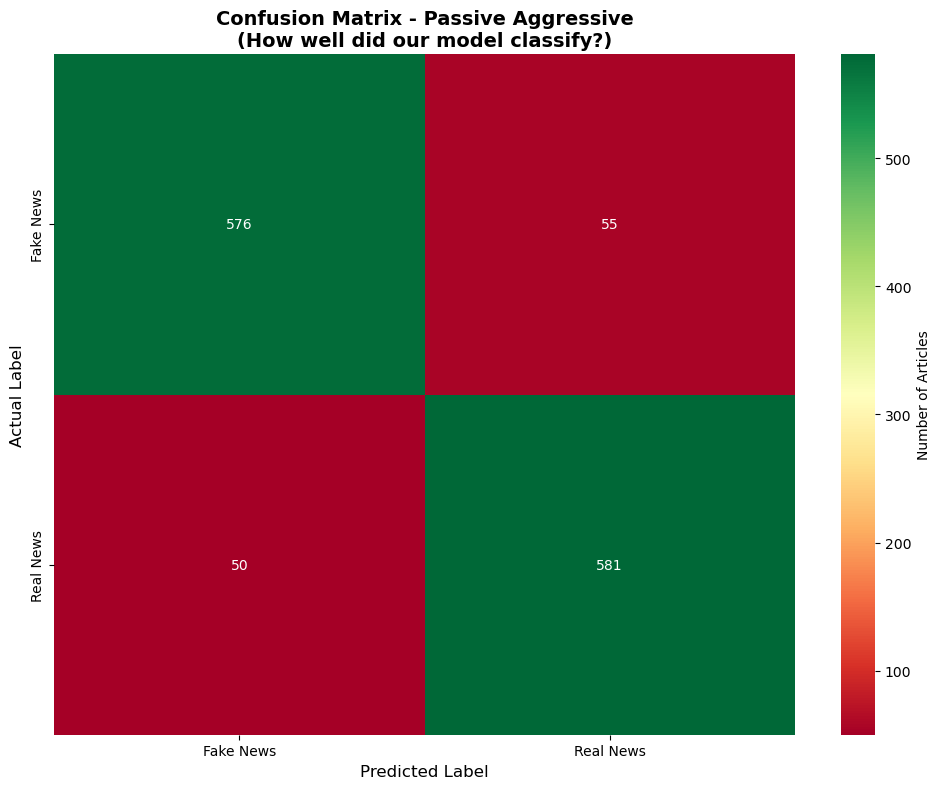

In [42]:
# Let's see where our model makes mistakes
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Fake News', 'Real News'], 
            yticklabels=['Fake News', 'Real News'],
            cbar_kws={'label': 'Number of Articles'})
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_model_name}\n(How well did our model classify?)', 
         fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [43]:
# Break down the numbers
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix Breakdown:")
print(f"  ✓ Correctly identified FAKE news: {tn} articles")
print(f"  ✗ Fake news wrongly called REAL: {fp} articles")
print(f"  ✗ Real news wrongly called FAKE: {fn} articles")
print(f"  ✓ Correctly identified REAL news: {tp} articles")



📊 Confusion Matrix Breakdown:
  ✓ Correctly identified FAKE news: 576 articles
  ✗ Fake news wrongly called REAL: 55 articles
  ✗ Real news wrongly called FAKE: 50 articles
  ✓ Correctly identified REAL news: 581 articles


 CELL 17: ROC Curve (If Applicable)

In [45]:
# ROC curve shows how well our model performs across different thresholds
if hasattr(best_model, 'predict_proba'):
    print("\nGenerating ROC curve...")
    
    # Get probability predictions
    y_proba = best_model.predict_proba(X_test_tfidf)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 7))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ ROC AUC Score: {roc_auc:.4f}")
    print(f"  (Closer to 1.0 is better!)")

 CELL 18: Feature Importance

In [46]:
# Let's see which words are most important for detection
if best_model_name in ['Logistic Regression', 'Naive Bayes']:
    print(f"\nAnalyzing important features for {best_model_name}...")
    
    # Get feature names
    feature_names = tfidf.get_feature_names_out()
    
    # Get coefficients/importance
    if best_model_name == 'Logistic Regression':
        importance = best_model.coef_[0]
    else:  # Naive Bayes
        importance = best_model.feature_log_prob_[1] - best_model.feature_log_prob_[0]
    
    # Get top features
    top_real_idx = np.argsort(importance)[-15:]  # Top 15 for real news
    top_fake_idx = np.argsort(importance)[:15]   # Top 15 for fake news
    
    print("\n🟢 Top 15 words indicating REAL NEWS:")
    for i, idx in enumerate(reversed(top_real_idx), 1):
        print(f"  {i}. {feature_names[idx]}")
    
    print("\n🔴 Top 15 words indicating FAKE NEWS:")
    for i, idx in enumerate(top_fake_idx, 1):
        print(f"  {i}. {feature_names[idx]}")


CELL 19: Create Prediction Function

In [47]:
def predict_news(article_text, model, vectorizer):
    """
    Predict if a news article is fake or real
    
    Parameters:
    article_text: The news article text to check
    model: Trained machine learning model
    vectorizer: TF-IDF vectorizer
    
    Returns:
    label: 'FAKE' or 'REAL'
    confidence: Confidence score (if available)
    """
    # Clean the text
    cleaned = clean_text(article_text)
    cleaned = remove_stopwords(cleaned)
    cleaned = lemmatize_text(cleaned)
    
    # Vectorize
    text_vectorized = vectorizer.transform([cleaned])
    
    # Predict
    prediction = model.predict(text_vectorized)[0]
    
    # Get confidence if possible
    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(text_vectorized)[0]
        confidence = probability[prediction] * 100
    else:
        confidence = None
    
    label = 'REAL' if prediction == 1 else 'FAKE'
    
    return label, confidence

print("\n✓ Prediction function ready!")



✓ Prediction function ready!


 CELL 20: Test with Sample Articles

In [48]:
# Let's test our model with some example news articles

sample_articles = [
    """
    Scientists at NASA announced today a groundbreaking discovery of water on Mars. 
    The findings, published in the journal Nature, show evidence of liquid water beneath 
    the planet's polar ice caps. This discovery could have significant implications for 
    future Mars missions and the search for extraterrestrial life.
    """,
    
    """
    BREAKING: President declares martial law after secret meeting with aliens! 
    Government insiders reveal shocking truth about UFO cover-up spanning decades. 
    Share this before they delete it! The mainstream media won't tell you this!
    """,
    
    """
    The stock market closed higher today as investors responded positively to the 
    latest economic data. The Dow Jones Industrial Average rose 250 points, while 
    the S&P 500 and Nasdaq also posted gains. Analysts attribute the rally to 
    better-than-expected employment figures released this morning.
    """
]

In [49]:
print("\n" + "=" * 80)
print("TESTING WITH SAMPLE ARTICLES")
print("=" * 80)

for i, article in enumerate(sample_articles, 1):
    print(f"\n📰 Article {i}:")
    print(f"Text preview: {article.strip()[:150]}...")
    
    label, confidence = predict_news(article, best_model, tfidf)
    
    print(f"\n🔍 Prediction: {label} NEWS")
    if confidence is not None:
        print(f"   Confidence: {confidence:.1f}%")
    print("-" * 80)




TESTING WITH SAMPLE ARTICLES

📰 Article 1:
Text preview: Scientists at NASA announced today a groundbreaking discovery of water on Mars. 
    The findings, published in the journal Nature, show evidence of l...

🔍 Prediction: FAKE NEWS
--------------------------------------------------------------------------------

📰 Article 2:
Text preview: BREAKING: President declares martial law after secret meeting with aliens! 
    Government insiders reveal shocking truth about UFO cover-up spanning ...

🔍 Prediction: FAKE NEWS
--------------------------------------------------------------------------------

📰 Article 3:
Text preview: The stock market closed higher today as investors responded positively to the 
    latest economic data. The Dow Jones Industrial Average rose 250 poi...

🔍 Prediction: FAKE NEWS
--------------------------------------------------------------------------------


CELL 21: Error Analysis

In [50]:
# Let's look at cases where our model made mistakes
misclassified = np.where(y_test.values != best_predictions)[0]

print(f"\n📉 Error Analysis:")
print(f"Total misclassified articles: {len(misclassified)}")
print(f"Misclassification rate: {len(misclassified)/len(y_test)*100:.2f}%")

if len(misclassified) > 0:
    print(f"\n🔍 Examples of Misclassified Articles:")
    print("=" * 80)
    
    # Show a few examples
    for i, idx in enumerate(misclassified[:3], 1):  # Show first 3
        original_idx = X_test.index[idx]
        true_label = 'REAL' if y_test.iloc[idx] == 1 else 'FAKE'
        pred_label = 'REAL' if best_predictions[idx] == 1 else 'FAKE'
        
        print(f"\nExample {i}:")
        print(f"  Actual: {true_label} | Predicted: {pred_label}")
        print(f"  Text preview: {df.loc[original_idx, 'content'][:200]}...")
        print("-" * 80)



📉 Error Analysis:
Total misclassified articles: 105
Misclassification rate: 8.32%

🔍 Examples of Misclassified Articles:

Example 1:
  Actual: FAKE | Predicted: FAKE
  Text preview: How To Repair Strained Or Broken Relationships A subject not often discussed is the topic of how to repair strained or broken relationships. It is one that comes up in everyone’s life, so it will be u...
--------------------------------------------------------------------------------

Example 2:
  Actual: FAKE | Predicted: FAKE
  Text preview: Cuba has a possible lung cancer vaccine that America can now test The United States and Cuba have taken major steps to end their 50 years of hostility, and some researchers think Americans could reap ...
--------------------------------------------------------------------------------

Example 3:
  Actual: FAKE | Predicted: FAKE
  Text preview: Profit sharing was supposed to be a silver bullet for middle-class success. What happened? The core commitment of the America